# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [247]:
STUDENT_NAME = "Võ Quỳnh Nhi"  
STUDENT_ID = "056306001950"    

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Võ Quỳnh Nhi (056306001950)


In [272]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\AD\Documents\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [249]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [250]:
# TODO N1
shifted_logits = logits - np.max(logits, axis = 1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis = 1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis = 1)
confidence_scores = np.max(class_probabilities , axis = 1)

In [251]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [252]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [253]:
# TODO N2
train_feature_mean = np.mean(X_train, axis = 0)
train_feature_std = np.std(X_train, axis = 0 )
X_train_scaled = (X_train - train_feature_mean)/train_feature_std
X_val_scaled = (X_val - train_feature_mean)/train_feature_std

In [254]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [255]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [256]:
# TODO N3
correct_mask = true_labels == predicted_classes
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [257]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [258]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis = 2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng là một mẫu xe trong bộ 1985 Auto Imports
2. Ký hiệu missing value trong CSV là gì
3. Mức đánh giá rủi ro bảo hiểm, thang từ -3 (an toàn hơn mức giá) đến 3 (rủi ro cao hơn mức giá).

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [259]:
# TODO D1
raw_df = pd.read_csv("data/automobile_raw.csv")
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [260]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [261]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()
print(missing_by_column)

symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

- Mỗi cột có ý nghĩa, đơn vị, thang giá trị khác nhau (`bore` ~inches vs `price` ~USD) → fill chung một giá trị (0, hoặc median toàn bảng) không có ý nghĩa vật lý.
- Mỗi cột có quan hệ khác nhau với các biến khác (vd. `horsepower` liên quan `engine_size`, `normalized_losses` liên quan `body_style`) → cần fill riêng, có thể theo nhóm thay vì global median.
- Tỷ lệ thiếu khác nhau → rủi ro làm méo phân phối khác nhau giữa các cột.

`price`: Drop hay Fill?
**->Drop** (chỉ thiếu ~2%, 4/205 dòng)
- `price` là biến mục tiêu/trung tâm của EDA → fill sẽ tạo dữ liệu giả cho chính biến cần phân tích, làm sai lệch mean/std/correlation.
- Tỷ lệ thiếu thấp → drop không mất nhiều thông tin.
- Không có nhóm phân loại đủ tin cậy để suy ra giá chính xác (giá biến động lớn ngay trong cùng hãng).

 `normalized_losses`: thiếu nhiều (~20%, 41/205) 
- **Không nên drop**: mất 20% dataset → lệch mẫu, mất các hãng/loại xe hiếm.
- **Fill median cũng rủi ro**: tạo cụm giá trị giống nhau chiếm 20% → giảm phương sai thật, làm mờ correlation với biến khác.
- Có thể là **MNAR** (Missing Not At Random) — xe đời cũ/hãng ít phổ biến có thể thiếu thống kê bảo hiểm không ngẫu nhiên.
- **Hướng xử lý:** không nằm trong 6 core analysis columns → có thể loại khỏi phân tích chính; nếu cần dùng, giữ NaN và `dropna()` cục bộ khi tính thống kê riêng cho cột này, thay vì fill đại trà.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [262]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [263]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis = 0)
auto_feature_std = np.std(X_auto, axis = 0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [264]:
# TODO D4
price_index = analysis_df["price"].to_numpy(dtype=np.float64)
price_z = (price_index - np.mean(price_index, axis = 0))/np.std(price_index, axis = 0)
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [265]:
# TODO D5
engine_price_corr = np.corrcoef(df_clean["engine_size"].to_numpy(), df_clean["price"].to_numpy())[0][1]
price_by_body_style = df_clean.groupby("body_style")["price"].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

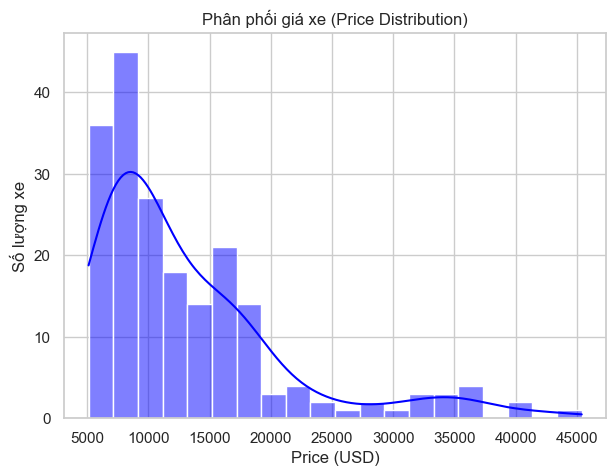

In [266]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(7, 5))  
sns.histplot(
    data=df_clean, x="price", kde=True, bins=20, color="blue"
) 
plt.title("Phân phối giá xe (Price Distribution)")
plt.xlabel("Price (USD)")
plt.ylabel("Số lượng xe")
plt.show()

**Nhận xét:** 
- Hình dáng: Đồ thị lệch phải rõ rệt 
- Phân bố giá: phần lớn tập trung chủ yếu ở khoảng 5000 - 18000 usd, một số xe cao cấp lên đến 45000 usd làm đuôi kéo dài bên phải

## M2.2 Dataset có cân bằng theo body style không?

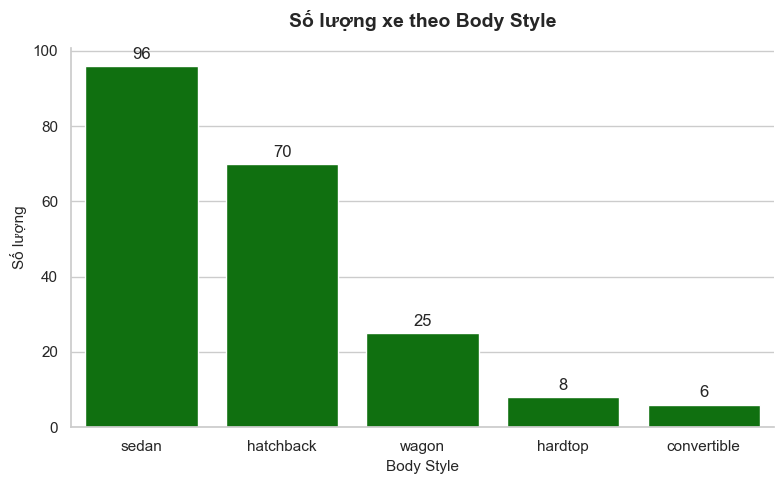

In [267]:
# TODO M2.2: countplot của body_style
fig, ax = plt.subplots(figsize=(8, 5))
order = df_clean["body_style"].value_counts().index
sns.countplot(data=df_clean, x="body_style", order=order, color="green", ax=ax)
for c in ax.containers:
    ax.bar_label(c, label_type='edge', padding=3)

ax.set_title("Số lượng xe theo Body Style", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Body Style", fontsize=11)
ax.set_ylabel("Số lượng", fontsize=11)
sns.despine()

plt.tight_layout()
plt.show()

**Nhận xét:** 
- `sedan` và `hatchback` chiếm phần lớn
- Ngược lại, `convertible`chỉ có 6 xe và `hardtop` có 8 xe 

## M2.3 Price khác nhau theo body style ra sao?

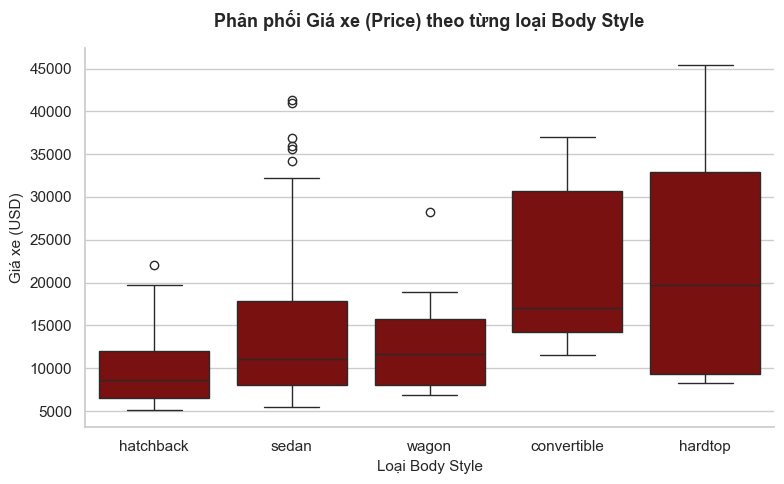

In [268]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots(figsize=(8, 5))
order = df_clean.groupby("body_style")["price"].median().sort_values().index

sns.boxplot(data=df_clean, x="body_style", y="price", order=order, ax=ax, color="darkred")
ax.set_title("Phân phối Giá xe (Price) theo từng loại Body Style", fontsize=13, pad=15, weight='bold')
ax.set_xlabel("Loại Body Style", fontsize=11)
ax.set_ylabel("Giá xe (USD)", fontsize=11)

sns.despine()

plt.tight_layout()
plt.show()

**Nhận xét:**
- `Hardtop` & `Convertible`: Giá trung vị dẫn đầu (19,700 - 17,000 USD) nhưng phương sai lớn (do cỡ mẫu nhỏ).

- `Hatchback`: Phân khúc giá rẻ nhất với mức trung vị khoảng 8,672 USD.

- `Sedan`: Khoảng giá trải rộng nhất thị trường và sở hữu nhiều biến động với lượng outlier lớn ở phía trên.

## M2.4 Engine size liên quan thế nào tới price?

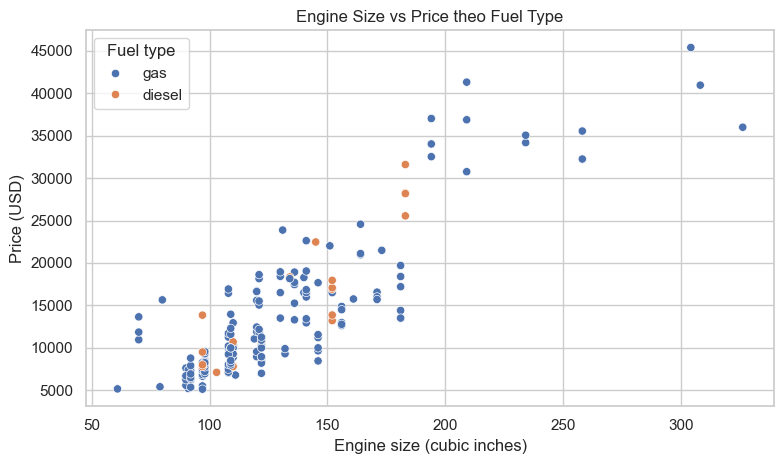

In [269]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots()
sns.scatterplot(data=df_clean, x="engine_size", y="price", hue="fuel_type", ax=ax)
ax.set_title("Engine Size vs Price theo Fuel Type")
ax.set_xlabel("Engine size (cubic inches)")
ax.set_ylabel("Price (USD)")
ax.legend(title="Fuel type")
plt.tight_layout()
plt.show()

**Nhận xét:** 
- Có mối tương quan thuận (dương) rất mạnh giữa kích thước động cơ (engine_size) và giá xe (price) với hệ số Pearson $r \approx 0.87$ 
=> nhóm xe chạy bằng diesel (quy mô nhỏ, 20 xe) chủ yếu tập trung ở phân khúc động cơ cỡ trung với mức giá vừa phải, không sở hữu các biến động giá vượt trội như một số mẫu xe chạy bằng gas ở phân khúc cao cấp.

## M2.5 Các feature numeric tương quan ra sao?

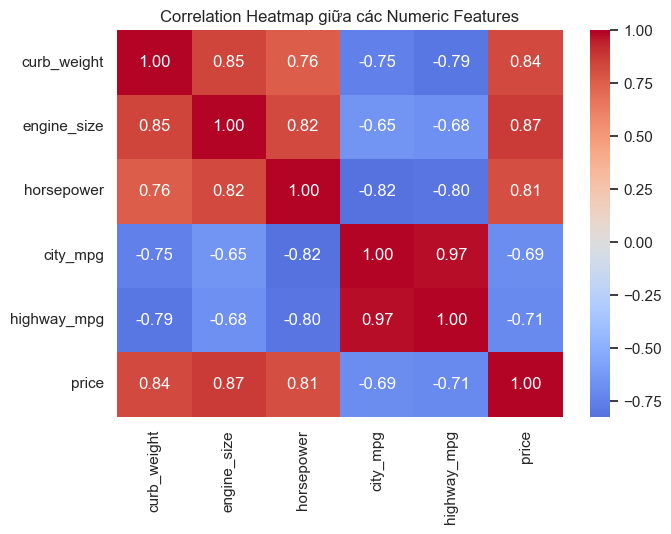

In [270]:
# TODO M2.5: correlation heatmap
corr_matrix = analysis_df.corr()
fig, ax = plt.subplots(figsize=(7, 5.5))

sns.heatmap(corr_matrix,
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm", 
            center=0, 
            ax=ax)
ax.set_title("Correlation Heatmap giữa các Numeric Features")
plt.tight_layout()
plt.show()

**Nhận xét:** 
- Hiệu suất nhiên liệu: `city_mpg` và `highway_mpg` đồng biến gần như tuyệt đối ($r \approx 0.97$) vì cùng đo lường một bản chất.
- Mối liên hệ Kỹ thuật – Giá thành - Nhiên liệu: * Cặp chỉ số Nặng hơn / Động cơ mạnh hơn (`curb_weight`, `engine_size`, `horsepower`) tỷ lệ thuận với Giá cao hơn ($r \approx 0.81 - 0.87$).

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

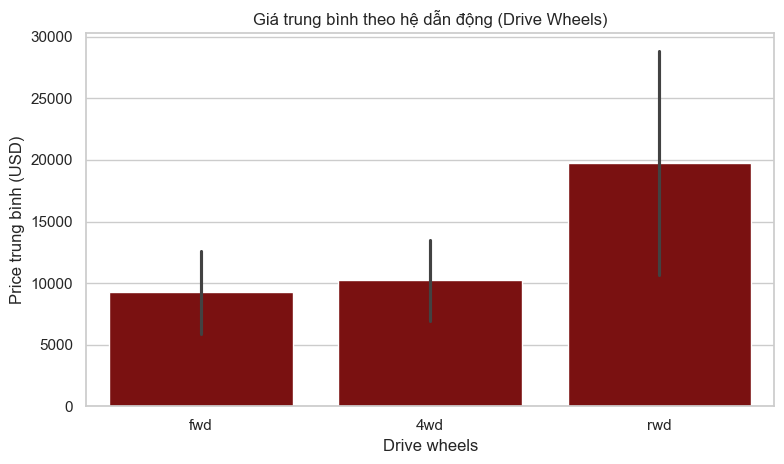

In [271]:
# TODO M2.6: biểu đồ tự chọn
# Câu hỏi: Hệ dẫn động (drive_wheels) có liên quan tới giá xe không?
fig, ax = plt.subplots()
order = df_clean.groupby("drive_wheels")["price"].mean().sort_values().index
sns.barplot(data=df_clean,
             x="drive_wheels", 
             y="price",
             order=order, 
             ax=ax, 
             color="darkred", 
             errorbar="sd")
ax.set_title("Giá trung bình theo hệ dẫn động (Drive Wheels)")
ax.set_xlabel("Drive wheels")
ax.set_ylabel("Price trung bình (USD)")
plt.tight_layout()
plt.show()

**Nhận xét:** Xe dẫn động cầu sau (`rwd`) có giá trung bình cao vượt trội (~19,758 USD) so với `4wd` (~10,241 USD) và `fwd` (~9,245 USD), phù hợp với thực tế `rwd` thường gắn với xe thể thao/hạng sang có động cơ mạnh hơn (horsepower trung bình ~134 hp so với ~86 hp của `fwd`).

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

## Tổng hợp của sinh viên

**Phát hiện chính:**
1. `price` lệch phải mạnh (skewness ≈ 1.81), đa số xe nằm trong khoảng 5,000–17,000 USD, chỉ một số ít xe cao cấp vượt 30,000 USD.
2. `engine_size` và `curb_weight` là hai yếu tố tương quan mạnh nhất với `price` (r ≈ 0.87 và 0.84), trong khi `city_mpg`/`highway_mpg` tương quan âm với `price` (xe tiết kiệm nhiên liệu thường rẻ hơn).
3. Dataset mất cân bằng theo `body_style`: `sedan` và `hatchback` chiếm gần 80% số xe, còn `convertible` chỉ có 6 mẫu — mọi so sánh theo nhóm nhỏ cần thận trọng.
4. Xe dẫn động `rwd` có giá trung bình cao gấp đôi `fwd`, đi kèm horsepower trung bình cao hơn đáng kể, phản ánh phân khúc xe thể thao/hạng sang.
5. `city_mpg` và `highway_mpg` gần như đo cùng một hiện tượng (r ≈ 0.97), có thể cân nhắc chỉ giữ một trong hai biến này khi xây model để tránh đa cộng tuyến.

**Hạn chế của dataset:**
- Cỡ mẫu nhỏ (205 dòng, còn 199 sau khi drop missing ở 6 core features) và phân bố lệch mạnh theo `body_style`/`drive_wheels`, khiến ước lượng cho các nhóm ít mẫu (`convertible`, `4wd`) kém tin cậy.
- Dữ liệu từ năm 1985 (Auto Imports), không phản ánh thị trường xe hiện tại (công nghệ động cơ, giá cả đã thay đổi nhiều).

**Ví dụ correlation không đồng nghĩa causation:** `engine_size` tương quan dương mạnh với `price`, nhưng không có nghĩa cứ tăng dung tích động cơ sẽ trực tiếp làm giá xe tăng — cả hai đều chịu ảnh hưởng chung từ một biến ẩn là *phân khúc/thương hiệu xe* (xe hạng sang vừa có động cơ lớn vừa được định giá cao vì thương hiệu, nội thất, công nghệ...).

**Câu hỏi nên phân tích tiếp:** Sau khi kiểm soát biến `make` (thương hiệu), liệu `engine_size` và `curb_weight` còn giữ được mức tương quan mạnh với `price` hay phần lớn hiệu ứng đã bị thương hiệu "hấp thụ"?